# 🏦 개인실습 — 한빛은행 스키마 구축 · 정답 모음

> 이 노트북은 `PostgreSQL_5_한빛은행_스키마_구축_개인실습.ipynb`(문제 노트북)의 **정답**입니다.
> 먼저 문제 노트북에서 **직접 풀어본 뒤에** 이 파일을 열어 확인하세요 — 바로 정답부터 보면 손에 남는 게 적습니다.
> 데이터·질문 순서는 문제 노트북과 완전히 동일합니다(실습 1~9). 아래 값들은 이 정답에서 넣는 시드 기준 **실측값**입니다.


---
## ⚙️ 준비 — psycopg 설치 + hanbit_bank DB 만들기


In [ ]:
# PostgreSQL 파이썬 드라이버(psycopg v3) 설치 — 이미 있으면 그대로 넘어갑니다
# 📖 문법 참고: %pip install은 주피터 노트북 안에서 pip 설치 명령을 바로 실행하는 매직 명령어입니다
#    (터미널에서 pip install을 치는 것과 같은 효과). -q는 설치 과정 로그를 줄여서(quiet) 조용히
#    설치하라는 옵션입니다. "psycopg[binary]"의 [binary]는 "psycopg 패키지의 binary라는 추가
#    기능 묶음(extras)도 같이 설치하라"는 뜻으로, 컴파일 없이 바로 쓸 수 있는 미리 빌드된 버전을
#    받습니다. 뒤에 이어진 python-dotenv는 .env 파일을 읽는 데 쓰는 별도 패키지입니다.
%pip install -q "psycopg[binary]" python-dotenv


In [ ]:
# (1) db-pg 컨테이너 안 PostgreSQL에 'hanbit_bank' DB를 만듭니다 (없을 때만 생성 → 재실행 안전)
# 아래는 Windows(cmd.exe) 기준입니다 — Linux/macOS는 바로 아래 주석 처리된 줄을 대신 쓰세요.
# 📖 문법 참고: psql -tc "SQL"의 -t는 헤더·구분선 없이 결과값만, -c는 그 SQL 하나만 실행하고
#    끝내라는 옵션입니다. findstr /C:"1" >NUL은 출력에서 문자 "1"을 찾되(화면 출력은 숨기고)
#    "찾았는지 여부"만 성공/실패로 남깁니다. A || B는 "A가 실패해야 B를 실행"이므로, 이 줄은
#    "hanbit_bank가 이미 있으면 넘어가고, 없으면 CREATE DATABASE로 새로 만든다"는 뜻입니다.
!docker exec db-pg psql -U postgres -tc "SELECT 1 FROM pg_database WHERE datname='hanbit_bank'" | findstr /C:"1" >NUL || docker exec db-pg psql -U postgres -c "CREATE DATABASE hanbit_bank"
# ---- Linux/macOS ----
# !docker exec db-pg psql -U postgres -tc "SELECT 1 FROM pg_database WHERE datname='hanbit_bank'" | grep -q 1 || docker exec db-pg psql -U postgres -c "CREATE DATABASE hanbit_bank"

# (2) 조회 결과를 한 줄씩 보기 좋게 출력하는 도우미
def run(sql):
    cur.execute(sql)
    rows = cur.fetchall()
    for row in rows:
        print(row)
    return rows

print("준비 완료 — hanbit_bank DB 확인/생성됨.")


---
## 🧪 실습 1 정답 — psycopg로 hanbit_bank에 연결

`.env`에서 비밀번호를 읽어와 `hanbit_bank`에 연결하고, 서버 버전을 확인합니다. (1교시 "Python에서 연결"과 동일한 패턴 — `dbname`만 다릅니다.)


In [ ]:
# ── 실습 1 정답 ──
# 📖 문법 참고: load_dotenv()·os.environ["PGPASSWORD"]는 1교시와 같은 패턴입니다(.env에서 비밀번호를
#    읽어와 코드에 직접 쓰지 않기 위함). cur.fetchone()은 fetchall()과 달리 결과의 "첫 행 하나만"
#    돌려줍니다 — SELECT version()처럼 결과가 한 행뿐일 때 자주 씁니다. [0]은 그 행(튜플)의
#    첫 번째 값을 꺼내는 것이고요. version()은 접속한 PostgreSQL 서버의 버전 문자열을 돌려주는
#    내장 함수로, 접속이 실제로 잘 됐는지 확인하는 용도로 자주 씁니다.
import psycopg, os
from dotenv import load_dotenv
load_dotenv()                                   # 같은 폴더의 .env → 환경변수
pw = os.environ["PGPASSWORD"]                   # 비밀번호는 .env 파일에 (하드코딩 금지)

conn = psycopg.connect(host="localhost", port=5432, dbname="hanbit_bank", user="postgres", password=pw)
cur = conn.cursor()
cur.execute("SELECT version();")
print(cur.fetchone()[0])
# → PostgreSQL 17.10 ... 으로 시작하는 문자열이 나오면 성공


---
## 🧪 실습 2 정답 — 스키마 구축: customers 표 ⭐

id는 자동증가 타입(`BIGSERIAL`)으로 선언합니다. 기존 표 3개를 먼저 정리해 재실행해도 안전하게 만듭니다.


In [ ]:
# ── 실습 2 정답 ──
# 📖 문법 참고: BIGSERIAL PRIMARY KEY는 "값을 안 넣으면 1,2,3...으로 자동으로 매기는 기본키"입니다.
#    DROP TABLE IF EXISTS a, b, c CASCADE처럼 표 여러 개를 한 번에 지울 수 있고, CASCADE는 그 표를
#    참조(REFERENCES)하는 다른 표까지 함께 지워줍니다(재실행해도 에러 없이 깨끗하게 다시 만들기
#    위한 습관). pg_tables는 PostgreSQL이 제공하는 시스템 뷰로, 현재 DB의 표 목록을 보여줍니다.
cur.execute("DROP TABLE IF EXISTS transactions, accounts, customers CASCADE")
cur.execute("""
CREATE TABLE customers (
    id BIGSERIAL PRIMARY KEY,
    name TEXT NOT NULL,
    grade TEXT,
    join_date TEXT
)
""")
conn.commit()
run("SELECT tablename FROM pg_tables WHERE schemaname='public' ORDER BY tablename")
# → ('customers',) 한 줄이 보이면 성공


🗺️ **오늘 만들 스키마의 ERD(설계도)** — 아래 실습들을 완성하면 이 구조가 완성됩니다.

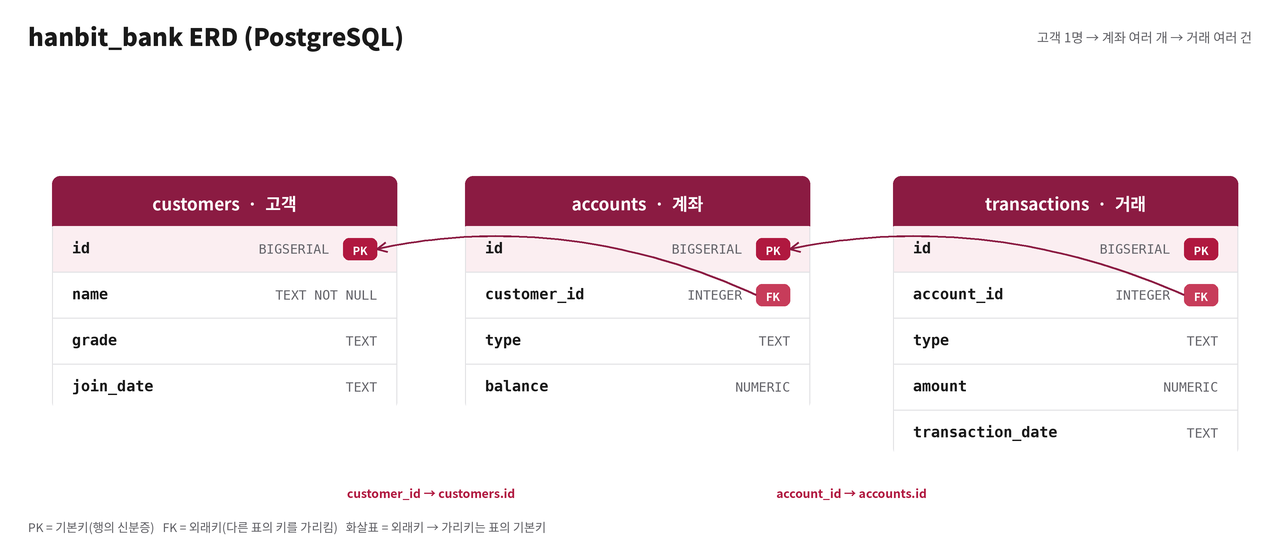

---
## 🧪 실습 3 정답 — 외래키로 연결: accounts·transactions ⭐

`accounts.customer_id`는 `customers(id)`를, `transactions.account_id`는 `accounts(id)`를 인라인 `REFERENCES`로 가리킵니다.


In [ ]:
# ── 실습 3 정답 ──
# 📖 문법 참고: INTEGER customer_id REFERENCES customers(id)처럼 컬럼 선언 바로 뒤에 REFERENCES를
#    붙이면 "이 컬럼의 값은 반드시 customers 표의 id 컬럼에 실제로 있는 값이어야 한다"는 외래키
#    제약이 걸립니다(없는 고객 id를 넣으려 하면 거부됨). 그래서 순서가 중요합니다 — accounts가
#    customers를, transactions가 accounts를 참조하므로 반드시 customers → accounts → transactions
#    순서로 만들어야 합니다(참조 대상이 먼저 존재해야 하기 때문). NUMERIC은 소수점을 오차 없이
#    정확하게 담는 타입으로, 잔액·금액처럼 정밀도가 중요한 값에 씁니다.
cur.execute("""
CREATE TABLE accounts (
    id BIGSERIAL PRIMARY KEY,
    customer_id INTEGER REFERENCES customers(id),
    type TEXT,
    balance NUMERIC
)
""")
cur.execute("""
CREATE TABLE transactions (
    id BIGSERIAL PRIMARY KEY,
    account_id INTEGER REFERENCES accounts(id),
    type TEXT,
    amount NUMERIC,
    transaction_date TEXT
)
""")
conn.commit()
run("SELECT tablename FROM pg_tables WHERE schemaname='public' ORDER BY tablename")
# → ('accounts',) ('customers',) ('transactions',) 3개 표가 보이면 성공


---
## 🧪 실습 4 정답 — 시드 적재 + commit ⭐

고객 5명 → 계좌 6개 → 거래 8건 순서로 넣습니다(부모 먼저, 외래키 있는 자식 나중). id는 전부 생략 — `BIGSERIAL`이 자동으로 매깁니다.
마지막에 **`conn.commit()`을 잊지 마세요** — 안 하면 저장되지 않습니다.


In [ ]:
# ── 실습 4 정답 ──
# 📖 문법 참고: 각 튜플(예: ("김철수", "VIP", "20230105")) 안의 값은 executemany의 SQL에 있는 %s
#    자리에 "순서대로" 채워집니다 — INSERT문에 적은 컬럼 순서(name, grade, join_date)와 튜플 안
#    값의 순서가 반드시 같아야 합니다. id를 안 넣는 이유는 BIGSERIAL이 자동으로 매기기 때문이고,
#    그래서 고객 5명을 먼저 넣어 id 1~5를 확정한 뒤에 계좌의 customer_id로 그 번호를 쓸 수 있는
#    것입니다(부모 먼저, 자식 나중인 이유).
customers = [   # (name, grade, join_date)
    ("김철수", "VIP", "20230105"),
    ("이영희", "우수", "20230312"),
    ("박민수", "일반", "20230520"),
    ("최지은", "우수", "20230815"),
    ("정우성", "일반", "20231102"),
]
accounts = [   # (customer_id, type, balance) — 삽입 순서가 곧 id 1..6
    (1, "입출금", 3500000), (1, "정기예금", 50000000),
    (2, "입출금", 650000),  (2, "적금", 7000000),
    (3, "적금", 5000000),
    (4, "입출금", 1000000),
    # 5번 고객(정우성)은 계좌가 하나도 없습니다 — 실습 8(LEFT JOIN)에서 이 점이 핵심입니다
]
transactions = [   # (account_id, type, amount, transaction_date)
    (1, "입금", 1000000, "20250601"), (1, "출금", 200000, "20250605"),
    (2, "입금", 50000000, "20250101"),
    (3, "입금", 650000, "20250310"),
    (4, "입금", 7000000, "20250115"),
    (5, "입금", 5000000, "20250220"),
    (6, "입금", 1000000, "20250405"),
    (1, "입금", 2700000, "20250610"),
]
cur.executemany("INSERT INTO customers (name, grade, join_date) VALUES (%s, %s, %s)", customers)
cur.executemany("INSERT INTO accounts (customer_id, type, balance) VALUES (%s, %s, %s)", accounts)
cur.executemany("INSERT INTO transactions (account_id, type, amount, transaction_date) VALUES (%s, %s, %s, %s)", transactions)
conn.commit()   # ✅ 포인트: commit 전엔 저장 안 됨 (psycopg autocommit=False)

# 📖 문법 참고: UNION ALL은 여러 SELECT 결과를 위아래로 이어 붙입니다(컬럼 개수·순서가 같아야 함).
#    'customers'처럼 따옴표로 감싼 문자열을 그냥 SELECT하면 그 값 자체가 결과의 한 컬럼이 되어,
#    이 결과가 어느 표의 집계인지 구분하는 라벨로 쓸 수 있습니다.
run("SELECT 'customers', min(id), max(id), count(*) FROM customers "
    "UNION ALL SELECT 'accounts', min(id), max(id), count(*) FROM accounts "
    "UNION ALL SELECT 'transactions', min(id), max(id), count(*) FROM transactions")
# → ('customers', 1, 5, 5) ('accounts', 1, 6, 6) ('transactions', 1, 8, 8)


---
## 🧪 실습 5 정답 — WHERE: 우수 등급 고객


In [ ]:
# ── 실습 5 정답 ──
run("SELECT name, grade FROM customers WHERE grade='우수' ORDER BY join_date")
# → ('이영희', '우수') ('최지은', '우수')  → 2명


---
## 🧪 실습 6 정답 — GROUP BY + SUM: 계좌 종류별 잔액 합계


In [ ]:
# ── 실습 6 정답 ──
run("SELECT type, SUM(balance) AS total FROM accounts GROUP BY type ORDER BY total DESC")
# → ('정기예금', Decimal('50000000')) ('적금', Decimal('12000000')) ('입출금', Decimal('5150000'))
# 💡 Decimal(...)로 보이는 이유: balance가 numeric 타입이라 SUM도 numeric(정확한 십진수)으로 나오기 때문. 값은 그대로.


---
## 🧪 실습 7 정답 — INNER JOIN: VIP 고객의 총 잔액 ⭐


In [ ]:
# ── 실습 7 정답 ──
run("SELECT c.name, SUM(a.balance) AS total FROM customers c "
    "JOIN accounts a ON c.id = a.customer_id "
    "WHERE c.grade='VIP' GROUP BY c.name")
# → ('김철수', Decimal('53500000'))  → 입출금 350만 + 정기예금 5,000만 = 5,350만원


---
## 🧪 실습 8 정답 — LEFT JOIN: 계좌 0인 고객까지 포함 ⭐


In [ ]:
# ── 실습 8 정답 ──
# ⚠️ 포인트: COUNT(*)가 아니라 COUNT(a.id) — LEFT JOIN에서 매칭 없는 행(NULL)을 0으로 세는 열쇠
run("SELECT c.name, COUNT(a.id) AS acc_cnt FROM customers c "
    "LEFT JOIN accounts a ON c.id = a.customer_id "
    "GROUP BY c.name ORDER BY acc_cnt DESC, c.name")
# → ('김철수', 2) ('이영희', 2) ('박민수', 1) ('최지은', 1) ('정우성', 0)
# 💡 정우성이 0으로 나오면 성공 — 그냥 JOIN(INNER)이었다면 정우성은 아예 사라졌을 것입니다.


---
## 🧪 실습 9 정답 — (도전) HAVING: 총잔액 2천만원 이상 고객 🚀


In [ ]:
# ── 실습 9 정답 ──
# 순서: WHERE(고르기) → GROUP BY(묶기) → 집계 → HAVING(묶은 결과 고르기) → ORDER BY(줄세우기)
run("SELECT c.name, SUM(a.balance) AS total FROM customers c "
    "JOIN accounts a ON c.id = a.customer_id "
    "GROUP BY c.name HAVING SUM(a.balance) >= 20000000 ORDER BY total DESC")
# → ('김철수', Decimal('53500000'))  → 2천만 이상은 김철수뿐


In [ ]:
# 실습을 마치며 연결을 닫습니다.
cur.close()
conn.close()
print("연결을 닫았습니다. 수고하셨습니다!")


---
## 🎉 정리 — 돌아보기 질문 답

1. **같은 SQL의 결과가 같았나요?** — 예. 달라진 건 자동증가(`BIGSERIAL`)·집계 타입(`Decimal`/numeric)·`GROUP BY` 엄격성·문자열은 작은따옴표·외래키 강제·`commit` 필요, 6가지입니다.
2. **`BIGSERIAL`을 쓰면 id를 안 넣어도 되는 이유** — 행이 들어올 때마다 PostgreSQL이 순번을 자동으로 매겨주기 때문입니다.
3. **`conn.commit()`을 빼먹으면?** — psycopg는 `autocommit=False`라서, commit 전까지는 다른 연결(DBeaver 등)에서 변경이 보이지 않고, 연결을 끊으면 사라질 수 있습니다.
4. **`INNER JOIN`과 `LEFT JOIN`의 차이** — INNER는 양쪽에 매칭이 있는 행만, LEFT는 왼쪽 표를 전부 남기고 매칭이 없으면 NULL(→ `COUNT`는 0)로 채웁니다. (정우성이 그 예)
5. **컨테이너를 지워도 데이터가 남는 이유** — 데이터는 컨테이너가 아니라 **볼륨**(`db-pg-data`)에 저장되기 때문입니다.
6. **`pgvector/pgvector` 이미지를 쓰는 이유** — 나중에 pgvector 기초에서 `CREATE EXTENSION`만 켜면 별도 이미지 재설치 없이 바로 벡터 검색을 쓸 수 있기 때문입니다.
